In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD DATA
df = pd.read_csv('indonesia_ecommerce_sales_challenging.csv', delimiter=';')

In [43]:
# 2. PENANGANAN TANGGAL & MISSING VALUES
# Menggunakan format mixed agar fleksibel dan menghapus data yang tanggalnya tidak valid
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce', format='mixed')
df = df.dropna(subset=['order_date'])

# Imputasi Missing Values pada kuantitas dan kategori string
df['total_qty'] = df['total_qty'].fillna(df['total_qty'].median())
df['Alasan Pembatalan'] = df['Alasan Pembatalan'].fillna('Tidak dibatalkan').str.strip()
df['Metode Pembayaran'] = df['Metode Pembayaran'].fillna('Other/Unknown')


In [44]:
# 3. STANDARISASI TEKS & PEMBERSIHAN KATEGORI
# Membersihkan kategori produk: Mengambil kata sebelum koma
df['product_categories'] = df['product_categories'].astype(str).str.split(',').str[0].str.strip().str.title()

# Menyamakan format teks dan menggabungkan alias metode pembayaran yang berulang
categorical_cols = ['Provinsi', 'Kota/Kabupaten', 'Opsi Pengiriman', 'product_categories', 'Metode Pembayaran']
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

mapping_metode = {
    'Saldo Shopeepay': 'Shopeepay',
    'Spaylater': 'Shopeepay',
    'Spay Later': 'Shopeepay',
    'Seabank Bayar Instan': 'Shopeepay',
    'Mitra Shopee': 'Shopeepay',
    'Cod (Bayar Di Tempat)': 'COD',
    'Cash On Delivery': 'COD',
    'Cod': 'COD',
    'Onlinepayment': 'Online Payment',
    'Cicilan Kartu Kredit': 'Kartu Kredit/Debit'
}
df['Metode Pembayaran'] = df['Metode Pembayaran'].replace(mapping_metode)


In [45]:
# 4. FEATURE ENGINEERING
# Membuat variabel baru: Selisih Ongkir dan Segmentasi Pelanggan
df['Gap_Ongkir'] = df['Perkiraan Ongkos Kirim'] - df['Ongkos Kirim Dibayar oleh Pembeli']
df['Segment_Pelanggan'] = np.where(df['total_qty'] > 10, 'Grosir', 'Retail')

In [46]:
# 5. DATA SPLITTING
# Memisahkan data transaksi sukses (df_final) dan transaksi batal (df_cancel)
df_final = df[df['Alasan Pembatalan'] == 'Tidak dibatalkan'].copy()
df_cancel = df[df['Alasan Pembatalan'] != 'Tidak dibatalkan'].copy()

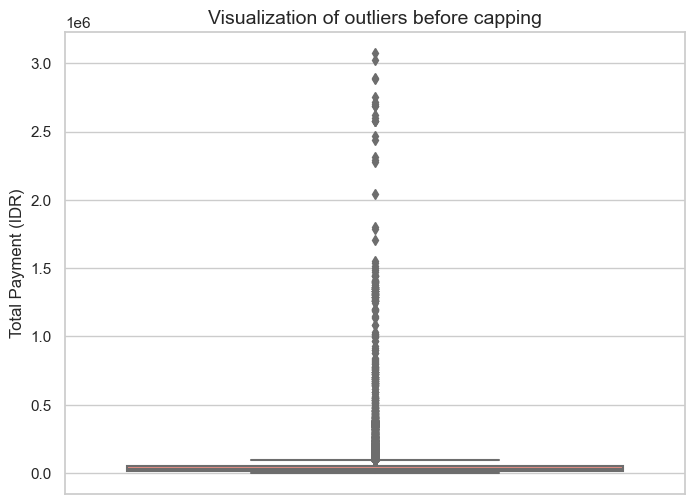

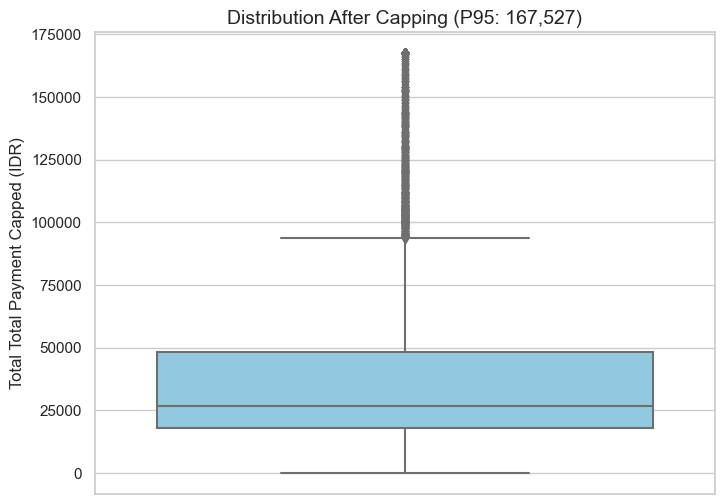

In [ ]:
# 6. OUTLIER HANDLING (CAPPING PERCENTILE 95)
upper_limit = df_final['Total Pembayaran'].quantile(0.95)
df_final['Total_Pembayaran_Capped'] = df_final['Total Pembayaran'].clip(upper=upper_limit)

# --- VISUALISASI BOXPLOT ---

# Boxplot Sebelum Capping
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_final['Total Pembayaran'], color='salmon')
plt.title('Visualization of outliers before capping', fontsize=14)
plt.ylabel('Total Payment (IDR)')
plt.show()

# Boxplot Sesudah Capping
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_final['Total_Pembayaran_Capped'], color='skyblue')
plt.title(f'Distribution After Capping (P95: {upper_limit:,.0f})', fontsize=14)
plt.ylabel('Total Total Payment Capped (IDR)')
plt.show()

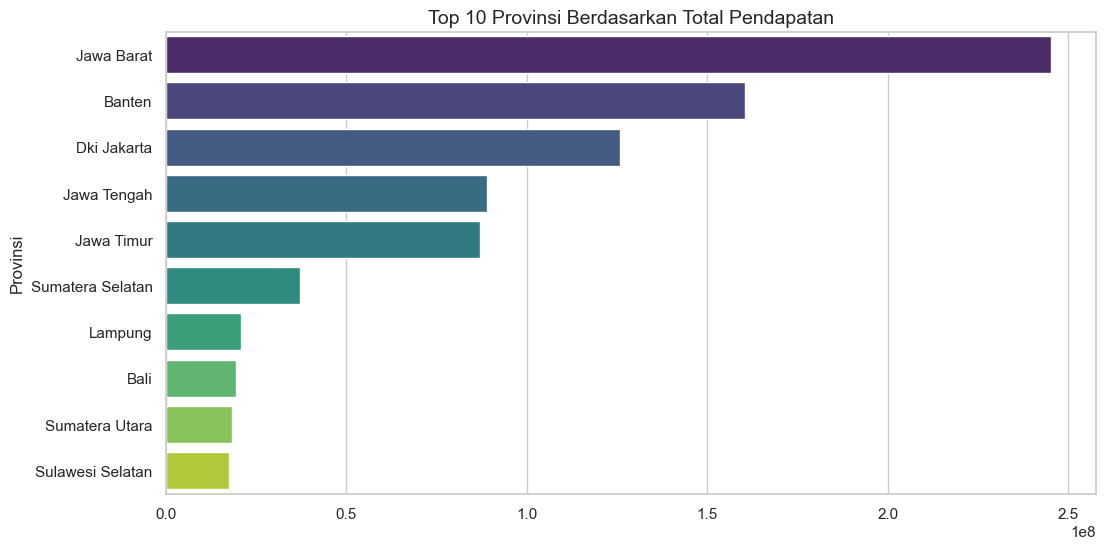

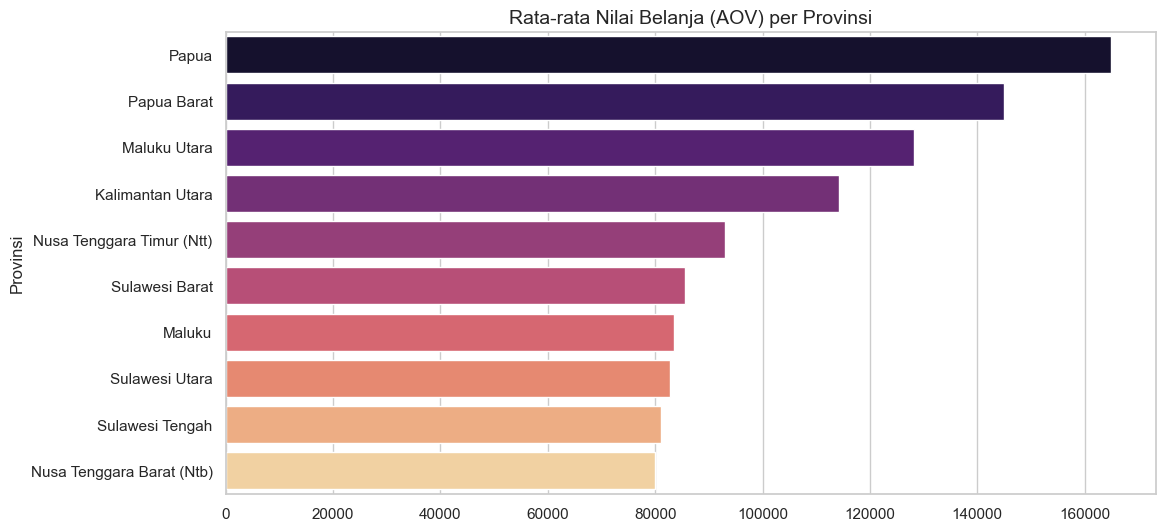

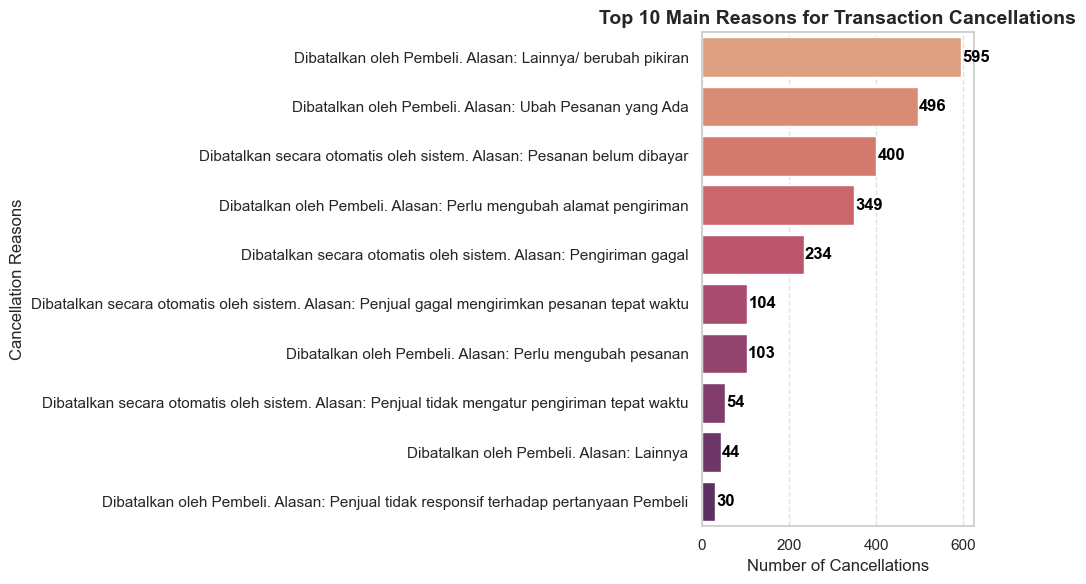

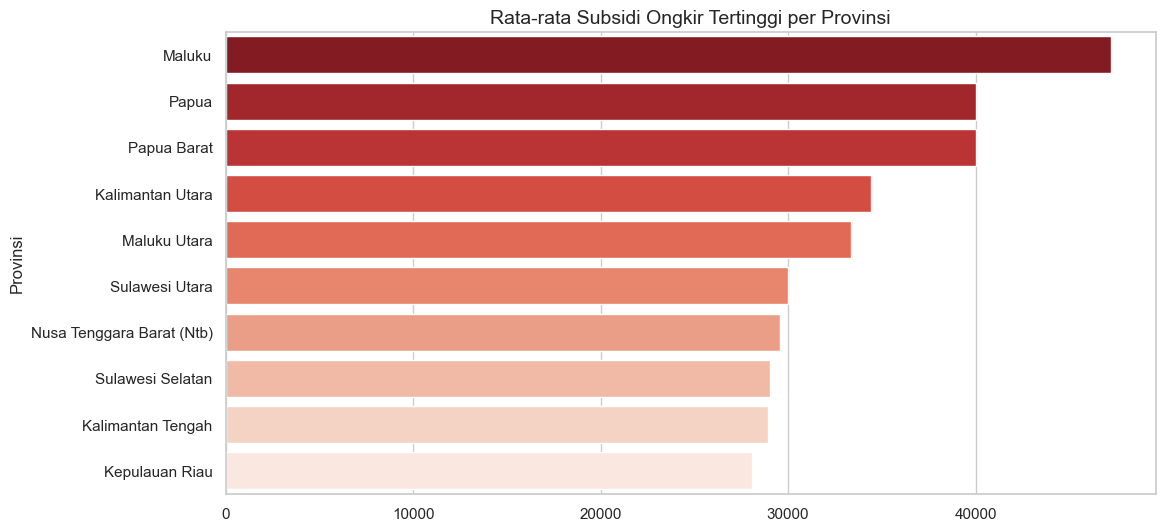

In [59]:
# 7. EXPLORATORY DATA ANALYSIS (EDA)
sns.set_theme(style="whitegrid")

# EDA 1: Top 10 Provinsi Berdasarkan Pendapatan
plt.figure(figsize=(12, 6))
top_rev = df_final.groupby('Provinsi')['Total Pembayaran'].sum().nlargest(10)
sns.barplot(x=top_rev.values, y=top_rev.index, palette='viridis')
plt.title('Top 10 Provinsi Berdasarkan Total Pendapatan', fontsize=14)
plt.show()

# EDA 2: Average Order Value (AOV) per Provinsi (Menggunakan Data Capped)
plt.figure(figsize=(12, 6))
top_aov = df_final.groupby('Provinsi')['Total_Pembayaran_Capped'].mean().nlargest(10)
sns.barplot(x=top_aov.values, y=top_aov.index, palette='magma')
plt.title('Rata-rata Nilai Belanja (AOV) per Provinsi', fontsize=14)
plt.show()

# EDA 3: Analisis Alasan Pembatalan Pesanan (Dari Data Cancel)
mapping_pembatalan = {
    'Dibatalkan oleh Pembeli. Alasan: Need to change delivery address': 'Dibatalkan oleh Pembeli. Alasan: Perlu mengubah alamat pengiriman'
}

df_cancel['Alasan Pembatalan Clean'] = df_cancel['Alasan Pembatalan'].replace(mapping_pembatalan)

# Ambil Top 10 Alasan
plt.figure(figsize=(10, 6))

# Hitung value counts dan ambil 10 teratas
cancel_counts = df_cancel['Alasan Pembatalan Clean'].value_counts().head(10)

# Buat Barplot
sns.barplot(x=cancel_counts.values, y=cancel_counts.index, palette='flare')

# Beri label angka di ujung bar agar informatif
for i, v in enumerate(cancel_counts.values):
    plt.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')

plt.title('Top 10 Main Reasons for Transaction Cancellations', fontsize=14, fontweight='bold')
plt.xlabel('Number of Cancellations')
plt.ylabel('Cancellation Reasons')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# EDA 4: Analisis Subsidi Ongkir (Gap Ongkir) Terbesar
plt.figure(figsize=(12, 6))
top_gap = df_final.groupby('Provinsi')['Gap_Ongkir'].mean().nlargest(10)
sns.barplot(x=top_gap.values, y=top_gap.index, palette='Reds_r')
plt.title('Rata-rata Subsidi Ongkir Tertinggi per Provinsi', fontsize=14)
plt.show()

In [62]:
# 3. Hitung Persentase (Normalize=True)
persentase_alasan = df_cancel['Alasan Pembatalan Clean'].value_counts(normalize=True) * 100

# 4. Tampilkan Top 10 beserta persentasenya
print("--- Top 10 Alasan Pembatalan (Persentase) ---")
print(persentase_alasan.head(10).apply(lambda x: f"{x:.2f}%"))

# 5. Hitung total kumulatif Top 2 (Berubah Pikiran + Ubah Alamat)
top_2_total = persentase_alasan.head(2).sum()
print(f"\nTotal Kontribusi Top 2 Alasan: {top_2_total:.2f}%")

--- Top 10 Alasan Pembatalan (Persentase) ---
Alasan Pembatalan Clean
Dibatalkan oleh Pembeli. Alasan: Lainnya/ berubah pikiran                                        23.38%
Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan yang Ada                                           19.49%
Dibatalkan secara otomatis oleh sistem. Alasan: Pesanan belum dibayar                            15.72%
Dibatalkan oleh Pembeli. Alasan: Perlu mengubah alamat pengiriman                                13.71%
Dibatalkan secara otomatis oleh sistem. Alasan: Pengiriman gagal                                  9.19%
Dibatalkan secara otomatis oleh sistem. Alasan: Penjual gagal mengirimkan pesanan tepat waktu     4.09%
Dibatalkan oleh Pembeli. Alasan: Perlu mengubah pesanan                                           4.05%
Dibatalkan secara otomatis oleh sistem. Alasan: Penjual tidak mengatur pengiriman tepat waktu     2.12%
Dibatalkan oleh Pembeli. Alasan: Lainnya                                                          

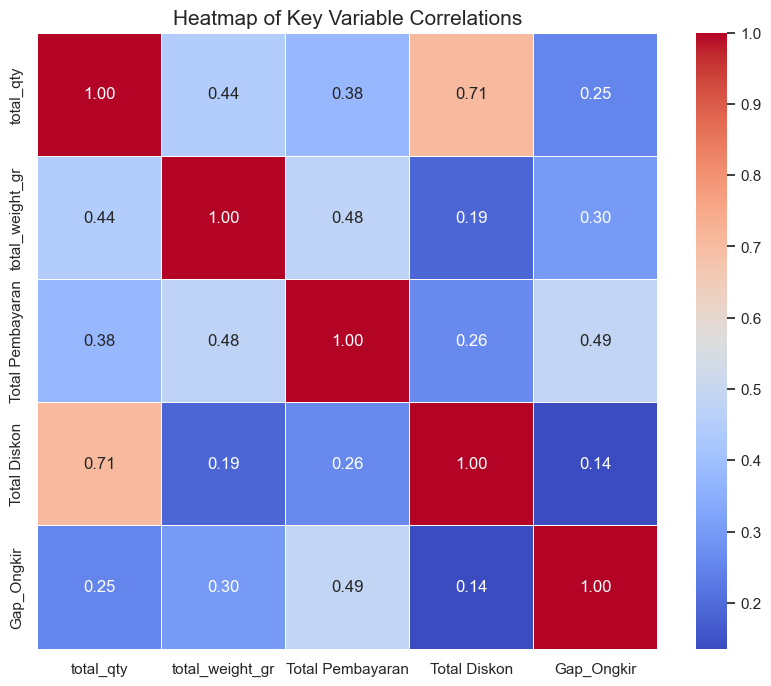

In [49]:
# 8. STATISTICAL ANALYSIS (HEATMAP KORELASI)
# Memilih hanya kolom yang krusial untuk insight
cols_filtered = ['total_qty', 'total_weight_gr', 'Total Pembayaran', 'Total Diskon', 'Gap_Ongkir']
corr_matrix = df_final[cols_filtered].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap of Key Variable Correlations', fontsize=15)
plt.show()

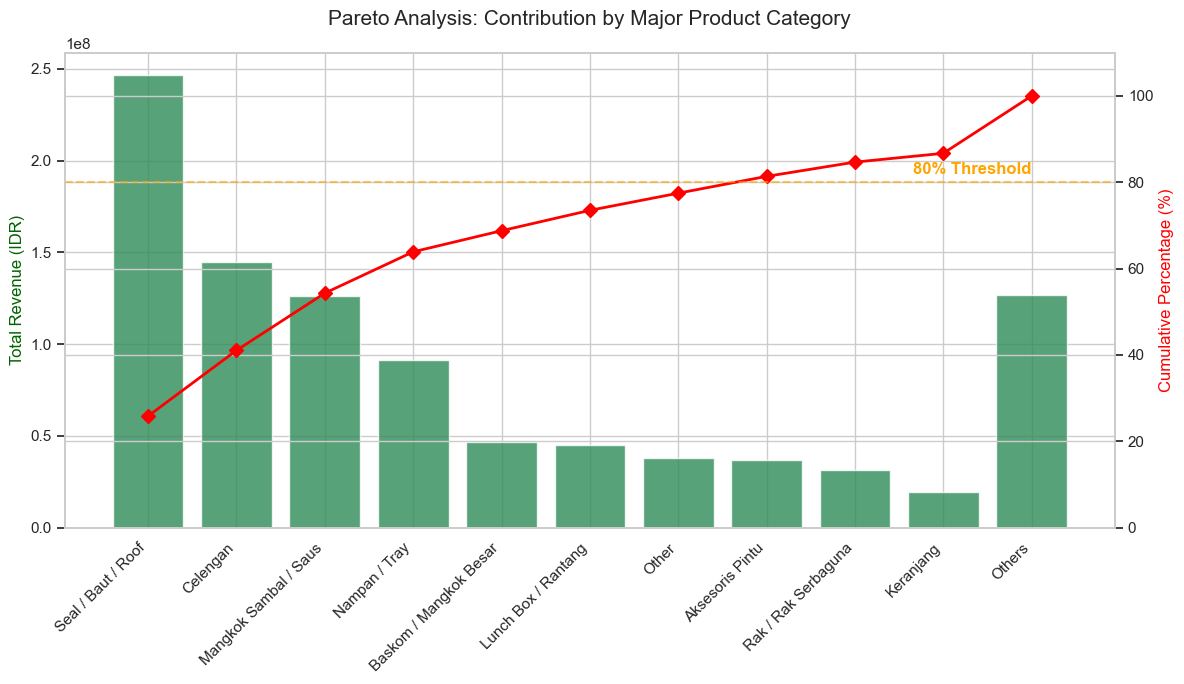

In [50]:
# 9. ADVANCED INSIGHT: PARETO ANALYSIS (80/20 RULE) - VERSI CLEAN
# Agregasi awal
data_pareto = df_final.groupby('product_categories')['Total Pembayaran'].sum().sort_values(ascending=False).reset_index()

# Ambil Top 10, sisanya masukkan ke 'Others'
top_n = 10
if len(data_pareto) > top_n:
    top_data = data_pareto.iloc[:top_n].copy()
    others_value = data_pareto.iloc[top_n:]['Total Pembayaran'].sum()
    others_df = pd.DataFrame({'product_categories': ['Others'], 'Total Pembayaran': [others_value]})
    data_pareto = pd.concat([top_data, others_df], ignore_index=True)

# Hitung ulang persentase kumulatif setelah penggabungan
data_pareto['cum_percentage'] = 100 * data_pareto['Total Pembayaran'].cumsum() / data_pareto['Total Pembayaran'].sum()

fig, ax1 = plt.subplots(figsize=(12, 7))

# Bar Chart
ax1.bar(data_pareto['product_categories'], data_pareto['Total Pembayaran'], color='seagreen', alpha=0.8)
ax1.set_ylabel('Total Revenue (IDR)', color='darkgreen', fontsize=12)
plt.xticks(rotation=45, ha='right') # Kemiringan diatur agar label panjang tidak tabrakan

# Line Chart (Kumulatif)
ax2 = ax1.twinx()
ax2.plot(data_pareto['product_categories'], data_pareto['cum_percentage'], color='red', marker='D', ms=7, linewidth=2)
ax2.axhline(80, color='orange', linestyle='--', alpha=0.6) # Garis ambang 80%

# Tambahkan label teks "80% Cut-off" agar lebih informatif
ax2.text(len(data_pareto)-1, 82, '80% Threshold', color='orange', fontweight='bold', ha='right')

ax2.set_ylabel('Cumulative Percentage (%)', color='red', fontsize=12)
ax2.set_ylim(0, 110)

plt.title('Pareto Analysis: Contribution by Major Product Category', fontsize=15, pad=20)
plt.tight_layout()
plt.show()

In [52]:
# 1. Hitung total revenue secara keseluruhan (menggunakan data yang sudah dibersihkan)
total_revenue_nasional = df_final['Total Pembayaran'].sum()

# 2. Hitung revenue spesifik untuk Jawa Barat dan DKI Jakarta
# Kita pakai .isin() agar efisien
target_provinces = ['Jawa Barat', 'Dki Jakarta']
revenue_target = df_final[df_final['Provinsi'].isin(target_provinces)]['Total Pembayaran'].sum()

# 3. Hitung persentasenya
percentage_contribution = (revenue_target / total_revenue_nasional) * 100

print(f"Total Revenue Nasional: Rp {total_revenue_nasional:,.0f}")
print(f"Total Revenue (Jabar + Jakarta): Rp {revenue_target:,.0f}")
print(f"Kontribusi Persentase: {percentage_contribution:.2f}%")

# --- TAMBAHAN: Untuk melihat Top 5 Provinsi agar datamu makin valid ---
top_5_provinces = df_final.groupby('Provinsi')['Total Pembayaran'].sum().nlargest(5)
top_5_percentage = (top_5_provinces / total_revenue_nasional) * 100

print("\n--- Top 5 Provinsi Contribution ---")
for prov, perc in top_5_percentage.items():
    print(f"{prov}: {perc:.2f}%")

Total Revenue Nasional: Rp 952,485,842
Total Revenue (Jabar + Jakarta): Rp 371,128,856
Kontribusi Persentase: 38.96%

--- Top 5 Provinsi Contribution ---
Jawa Barat: 25.75%
Banten: 16.84%
Dki Jakarta: 13.21%
Jawa Tengah: 9.35%
Jawa Timur: 9.14%
